# PicMin — repeated adaptation across the 31 site-lineages: SV vs SNP

Faithful-Python PicMin (Booker et al.): sites = lineages; per-site per-locus statistic = drift-
controlled parallelism |z|; convert to empirical p vs the SNP |z| distribution in each p0-bin; the
a-th smallest p across lineages ~ Beta(a, N−a+1); stat = min_a F_Beta; uniform-null-calibrated
per-locus p → BH-FDR. Are SVs over-represented among repeated-adaptation loci vs frequency-matched
SNPs? (Climate-agnostic direct contrast.)

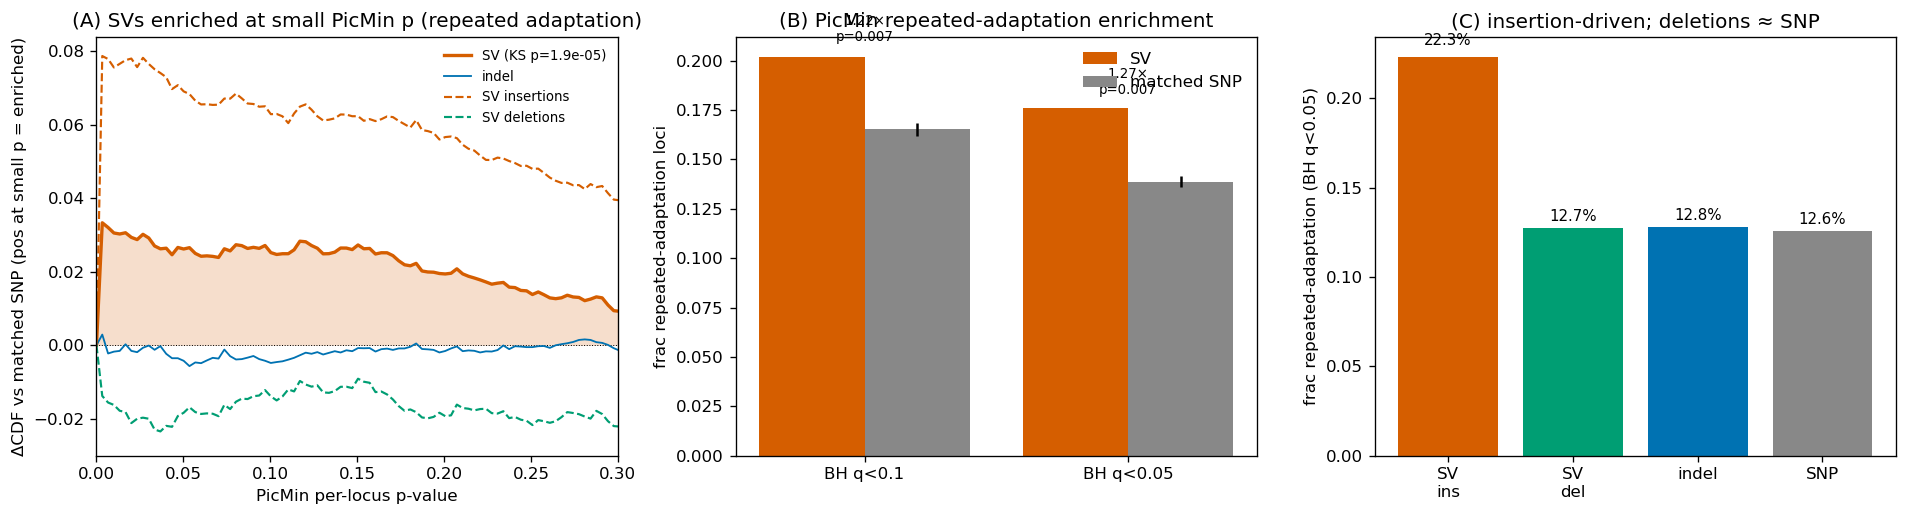

PicMin BH q<0.05: SV 17.6% (ins 22.3%, del 12.7%), matched-SNP 13.8%


In [1]:

import numpy as np, matplotlib.pyplot as plt
from scipy import stats
plt.rcParams.update({'figure.dpi':120,'font.size':10})
G="/global/scratch/users/tbellg/kmate/results/grenenet_gea/sv_adaptive"
z=np.load(f"{G}/picmin.npz"); rng=np.random.default_rng(0)
COL={"SV":"#D55E00","SNP":"#888888","indel":"#0072B2","ins":"#D55E00","del":"#009E73"}
p_sv,p_in,p_sn=z["p_sv"],z["p_indel"],z["p_snp"]; p0sv,p0sn=z["p0_sv"],z["p0_snp"]; isd=z["isdel_sv"]
def match(tp0,val,sp0):
    e=np.quantile(np.concatenate([tp0,sp0]),np.linspace(0,1,26)); e[-1]+=1e-9
    tb=np.digitize(tp0,e[1:-1]); sb=np.digitize(sp0,e[1:-1]); out=[]
    for k in range(25):
        pool=val[sb==k]; nn=int(round((tb==k).mean()*20000))
        if nn and pool.size: out.append(rng.choice(pool,nn,replace=True))
    return np.concatenate(out)
def bh(p,q):
    o=np.argsort(p); n=len(p); below=p[o]<=q*np.arange(1,n+1)/n
    k=np.where(below)[0].max()+1 if below.any() else 0
    s=np.zeros(n,bool); s[o[:k]]=True; return s

fig,ax=plt.subplots(1,3,figsize=(16,4.4))
# (A) ECDF-difference of PicMin p-values (excess of SMALL p = repeated-adaptation enrichment)
msn=match(p0sv,p_sn,p0sn); grid=np.linspace(0,1,300); cdf=lambda s:np.searchsorted(np.sort(s),grid,side="right")/s.size
base=cdf(msn)
ax[0].axhline(0,color="k",lw=.6,ls=":")
ax[0].fill_between(grid,0,cdf(p_sv)-base,color=COL["SV"],alpha=.2,lw=0)
ax[0].plot(grid,cdf(p_sv)-base,color=COL["SV"],lw=2,label=f"SV (KS p={stats.ks_2samp(p_sv,msn).pvalue:.1e})")
ax[0].plot(grid,cdf(match(p0sv,p_in,z['p0_indel']))-base,color=COL["indel"],lw=1.1,label="indel")
ax[0].plot(grid,cdf(p_sv[~isd])-base,color=COL["ins"],lw=1.3,ls="--",label="SV insertions")
ax[0].plot(grid,cdf(p_sv[isd])-base,color=COL["del"],lw=1.3,ls="--",label="SV deletions")
ax[0].set_xlabel("PicMin per-locus p-value"); ax[0].set_ylabel("ΔCDF vs matched SNP (pos at small p = enriched)")
ax[0].set_title("(A) SVs enriched at small PicMin p (repeated adaptation)"); ax[0].legend(frameon=False,fontsize=8)
ax[0].set_xlim(0,0.3)
# (B) FDR-significant fraction, SV vs matched-SNP, bootstrap
qs=[0.10,0.05]; xs=np.arange(len(qs)); ob=[]; nb_=[]; eb=[]; pb=[]
for q in qs:
    sig_sv=bh(p_sv,q); o=sig_sv.mean()
    nd=np.array([bh(match(p0sv,p_sn,p0sn),q).mean() for _ in range(150)])
    ob.append(o); nb_.append(nd.mean()); eb.append(nd.std()); pb.append((np.sum(nd>=o)+1)/151)
ax[1].bar(xs-0.2,ob,0.4,color=COL["SV"],label="SV"); ax[1].bar(xs+0.2,nb_,0.4,yerr=eb,color=COL["SNP"],label="matched SNP")
for i,(o,n,p) in enumerate(zip(ob,nb_,pb)): ax[1].text(i,max(o,n)*1.04,f"{o/n:.2f}×\np={p:.3f}",ha="center",fontsize=8)
ax[1].set_xticks(xs); ax[1].set_xticklabels([f"BH q<{q}" for q in qs]); ax[1].set_ylabel("frac repeated-adaptation loci")
ax[1].set_title("(B) PicMin repeated-adaptation enrichment"); ax[1].legend(frameon=False)
# (C) insertion vs deletion FDR fraction
q=0.05; sig_sv=bh(p_sv,q)
cats=["SV\nins","SV\ndel","indel","SNP"]; vals=[sig_sv[~isd].mean(), sig_sv[isd].mean(), bh(p_in,q).mean(), bh(p_sn,q).mean()]
ax[2].bar(cats,vals,color=[COL["ins"],COL["del"],COL["indel"],COL["SNP"]])
for i,v in enumerate(vals): ax[2].text(i,v*1.03,f"{v*100:.1f}%",ha="center",fontsize=9)
ax[2].set_ylabel(f"frac repeated-adaptation (BH q<{q})"); ax[2].set_title("(C) insertion-driven; deletions ≈ SNP")
fig.tight_layout(); fig.savefig(f"{G}/picmin.png",dpi=130,bbox_inches="tight"); plt.show()
print(f"PicMin BH q<0.05: SV {sig_sv.mean()*100:.1f}% (ins {sig_sv[~isd].mean()*100:.1f}%, del {sig_sv[isd].mean()*100:.1f}%), "
      f"matched-SNP {bh(match(p0sv,p_sn,p0sn),0.05).mean()*100:.1f}%")


### Reading
- **(A)** SVs have an excess of *small* PicMin p-values vs frequency-matched SNPs (positive ΔCDF near
  0) → over-represented among repeated-adaptation loci. Insertion-driven; deletions ≈ 0.
- **(B)** Frequency-matched FDR contrast: SVs enriched ~1.2–1.3× at BH q<0.1 / q<0.05.
- **(C)** Insertions carry it (deletions ≈ the SNP baseline).
- *Absolute* significant fraction is high because this founder-projection system has pervasive
  parallel sorting — the SV-vs-SNP **relative** contrast is the signal. Same caveats: founder
  projection + insertion-polarity.